# Phase 2 - Shah et al. Table I Reproduction


Closes the reproduction-fidelity gap: our earlier code could not hit Shah's small parameter counts. This notebook builds **two** models at Shah's exact budget (74/189/600 for n=3/4/5):

1. **Shah-faithful** - 8-layer RX + full-entanglement VQC, **probability state-vector** measurement, a **single** small classical hidden layer, **Adam only**, fixed input scale. This mirrors Shah's reported architecture and validates our implementation against his reported accuracy (~10^-3 at 5 qubits; poor at 3).
2. **Our-recipe (same budget)** - the validated Tier-1/2 recipe (data re-uploading, trainable input scale, L-BFGS + curriculum) but **shrunk to the same ~74/189/600 params**, isolating what our *procedure* buys at *identical capacity*.



## 1. Dependencies (run once)

In [1]:
import importlib, subprocess, sys
def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg); print(f"[ok] {pkg}")
    except ImportError:
        print(f"[..] installing {pipname or pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pipname or pkg])
for p in ["torch", "pennylane", "scipy", "numpy", "matplotlib"]:
    ensure(p)
print("[done]")

[ok] torch
[ok] pennylane
[ok] scipy
[ok] numpy
[ok] matplotlib
[done]


## 2. Imports & configuration

In [2]:
import os, time, math, json
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
from scipy.stats import qmc
import matplotlib.pyplot as plt

SEED = 1234
np.random.seed(SEED); torch.manual_seed(SEED)
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CKPT_ROOT = "qapinn_runs_shah"
for sub in ["checkpoints", "results", "figures", "models"]:
    os.makedirs(os.path.join(CKPT_ROOT, sub), exist_ok=True)
N_U = 120
print(f"[cfg] torch {torch.__version__} | pennylane {qml.__version__} | {device} | {DTYPE}")
print(f"[cfg] outputs -> {CKPT_ROOT}/  | quantum sim: default.qubit (backprop) on {device}")

[cfg] torch 2.10.0 | pennylane 0.45.1 | cpu | torch.float32
[cfg] outputs -> qapinn_runs_shah/  | quantum sim: default.qubit (backprop) on cpu


## 3. PDEs + training-data maker

In [3]:
NU_EASY  = 0.05
NU_HARD  = 0.01/np.pi
ALPHA    = 0.10

def initial_condition(pde, x):
    return -np.sin(np.pi*x) if pde == "burgers" else np.sin(np.pi*x)

def make_training_data(pde, n_f, tmax=1.0, shock_frac=0.0, seed=SEED):
    rng = np.random.default_rng(seed)
    n_ic = N_U // 2
    x_ic = rng.uniform(-1, 1, n_ic); t_ic = np.zeros(n_ic)
    u_ic = initial_condition(pde, x_ic)
    n_bc = N_U - n_ic
    t_bc = rng.uniform(0, tmax, n_bc)
    x_bc = np.where(rng.random(n_bc) < 0.5, -1.0, 1.0)
    u_bc = np.zeros(n_bc)
    x_u = np.concatenate([x_ic, x_bc]).reshape(-1, 1)
    t_u = np.concatenate([t_ic, t_bc]).reshape(-1, 1)
    u_u = np.concatenate([u_ic, u_bc]).reshape(-1, 1)
    n_sh = int(shock_frac * n_f) if pde == "burgers" else 0
    n_lhs = n_f - n_sh
    lhs = qmc.LatinHypercube(d=2, seed=seed)
    s = lhs.random(n_lhs)
    x_f1 = -1.0 + 2.0*s[:, 0]; t_f1 = tmax*s[:, 1]
    x_f2 = np.clip(rng.normal(0.0, 0.15, n_sh), -1, 1)
    t_f2 = rng.uniform(0.25*tmax, tmax, n_sh)
    x_f = np.concatenate([x_f1, x_f2]).reshape(-1, 1)
    t_f = np.concatenate([t_f1, t_f2]).reshape(-1, 1)
    T = lambda a: torch.tensor(a, dtype=DTYPE, device=device)
    return T(x_u), T(t_u), T(u_u), T(x_f), T(t_f)
print("[ok] data maker ready")

[ok] data maker ready


## 4. Reference solutions (exact, cached)

In [4]:
def burgers_analytical(x_arr, t_arr, nu, n_quad=4000):
    x_arr = np.atleast_1d(np.asarray(x_arr, float)); t_arr = np.atleast_1d(np.asarray(t_arr, float))
    u = np.zeros((len(t_arr), len(x_arr)))
    y = np.linspace(-3.0, 3.0, n_quad)
    cos_term = np.cos(np.pi*y) / (2.0*np.pi*nu)
    for i, ti in enumerate(t_arr):
        if ti < 1e-12:
            u[i, :] = -np.sin(np.pi*x_arr); continue
        F = cos_term.reshape(1, -1) + (x_arr.reshape(-1, 1) - y.reshape(1, -1))**2/(4.0*nu*ti)
        ml = np.max(-F, axis=1, keepdims=True); w = np.exp(-F - ml)
        num = np.sum((x_arr.reshape(-1, 1) - y.reshape(1, -1))/ti * w, axis=1)
        den = np.sum(w, axis=1)
        u[i, :] = np.where(den > 0, num/den, 0.0)
    return u

_REFS = {}
def reference(pde, nu):
    key = (pde, round(float(nu), 8))
    if key in _REFS: return _REFS[key]
    path = os.path.join(CKPT_ROOT, "results", f"ref_{pde}_{nu:.6f}.npz")
    if os.path.exists(path):
        d = np.load(path); out = (d["x"], d["t"], d["U"])
    else:
        x = np.linspace(-1, 1, 256); t = np.linspace(0, 1, 256)
        if pde == "heat":
            U = np.sin(np.pi*x)[None, :] * np.exp(-nu*np.pi**2*t)[:, None]
        else:
            print(f"[ref] computing Cole-Hopf for nu={nu:.5f} (once, ~20s)...")
            U = burgers_analytical(x, t, nu)
        np.savez(path, x=x, t=t, U=U); out = (x, t, U)
    _REFS[key] = out
    return out

@torch.no_grad()
def relative_l2(model, pde, nu):
    x, t, U = reference(pde, nu)
    XX, TT = np.meshgrid(x, t)
    xf = torch.tensor(XX.reshape(-1, 1), dtype=DTYPE, device=device)
    tf = torch.tensor(TT.reshape(-1, 1), dtype=DTYPE, device=device)
    up = model(xf, tf).cpu().numpy().reshape(U.shape)
    return float(np.linalg.norm(up - U)/np.linalg.norm(U)), up

def frozen_ic_baseline(pde, nu):
    x, t, U = reference(pde, nu)
    IC = np.tile(initial_condition(pde, x), (len(t), 1))
    return float(np.linalg.norm(IC - U)/np.linalg.norm(U))
print("[ok] references ready")

[ok] references ready


## 5. QAPINN model (validated architecture)

In [5]:
def build_qnode(n_qubits, n_layers, entanglement="all", measurement="expval",
                encoding_reps=None):
    dev = qml.device("default.qubit", wires=n_qubits)
    reps = n_layers if encoding_reps is None else encoding_reps
    def entangle():
        if entanglement == "none": return
        if entanglement == "linear":
            for q in range(n_qubits - 1): qml.CNOT(wires=[q, q + 1])
        elif entanglement == "all":
            for a in range(n_qubits):
                for b in range(a + 1, n_qubits): qml.CNOT(wires=[a, b])
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        for l in range(n_layers):
            if l < reps:
                for q in range(n_qubits):
                    qml.RY(inputs[:, q % 2], wires=q)
            for q in range(n_qubits):
                qml.RX(weights[l, q], wires=q)
            entangle()
        if measurement == "expval":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        return qml.probs(wires=range(n_qubits))
    out_dim = n_qubits if measurement == "expval" else 2**n_qubits
    return circuit, {"weights": (n_layers, n_qubits)}, out_dim


class QAPINN(nn.Module):
    """VQC first layer (re-uploading, trainable input scale) + deep classical body."""
    def __init__(self, n_qubits=3, n_layers=6, entanglement="all", measurement="expval",
                 encoding_reps=None, head_width=20, head_depth=5):
        super().__init__()
        self.cfg = dict(n_qubits=n_qubits, n_layers=n_layers, entanglement=entanglement,
                        measurement=measurement,
                        encoding_reps=(n_layers if encoding_reps is None else encoding_reps),
                        head_width=head_width, head_depth=head_depth)
        qnode, wshapes, out_dim = build_qnode(n_qubits, n_layers, entanglement,
                                              measurement, encoding_reps)
        self.qlayer = qml.qnn.TorchLayer(qnode, wshapes)
        self.in_scale = nn.Parameter(torch.ones(2))
        layers = [nn.Linear(out_dim, head_width), nn.Tanh()]
        for _ in range(head_depth - 1):
            layers += [nn.Linear(head_width, head_width), nn.Tanh()]
        layers += [nn.Linear(head_width, 1)]
        self.head = nn.Sequential(*layers)
        for m in self.head:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * self.in_scale * math.pi
        feat = self.qlayer(inp)
        return self.head(feat)

def count_params(model):
    return sum(p.numel() for p in model.parameters())
print("[ok] QAPINN ready")

[ok] QAPINN ready


## 6. Physics-informed loss

In [6]:
W_IC = 10.0
def pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde, nu, w_ic=None):
    w = W_IC if w_ic is None else w_ic
    u_pred = model(x_u, t_u)
    mse_u = torch.mean((u_pred - u_u)**2)
    xf = x_f.clone().requires_grad_(True)
    tf = t_f.clone().requires_grad_(True)
    u = model(xf, tf)
    u_x = torch.autograd.grad(u, xf, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, tf, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xf, torch.ones_like(u_x), create_graph=True)[0]
    if pde == "burgers":
        f = u_t + u*u_x - nu*u_xx
    else:
        f = u_t - nu*u_xx
    mse_f = torch.mean(f**2)
    return w*mse_u + mse_f, mse_u, mse_f
print("[ok] loss ready")

[ok] loss ready


## 7. Training engine (checkpointed, timed)

In [7]:
def ckpt_path(tag):
    return os.path.join(CKPT_ROOT, "checkpoints", f"{tag}.pt")

def _state_copy(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def train_schedule(tag, model, pde, nu, schedule, n_f=2000, ckpt_every=250, log_every=500):
    model.to(device)
    hist = {"iters": [], "loss": [], "mse_u": [], "mse_f": [], "phase": []}
    start_phase, start_it, opt_state = 0, 0, None
    best_loss, best_state = float("inf"), None
    p = ckpt_path(tag)
    if os.path.exists(p):
        ck = torch.load(p, map_location=device, weights_only=False)
        model.load_state_dict(ck["model_state"]); hist = ck["history"]
        start_phase, start_it = ck["phase"], ck["it"]
        opt_state = ck.get("opt_state")
        best_loss = ck.get("best_loss", best_loss); best_state = ck.get("best_state")
        print(f"[resume] '{tag}' at phase {start_phase}, it {start_it}")
    if start_phase >= len(schedule):
        print(f"[done] '{tag}' already finished. Delete its checkpoint to redo.")
        return hist
    cur = {"phase": start_phase, "it": start_it, "opt": None}
    def save():
        tmp = p + ".tmp"
        torch.save({"phase": cur["phase"], "it": cur["it"],
                    "model_state": model.state_dict(),
                    "opt_state": (cur["opt"].state_dict() if cur["opt"] is not None else None),
                    "history": hist, "best_loss": best_loss, "best_state": best_state}, tmp)
        os.replace(tmp, p)
    gstep = len(hist["loss"])
    t0 = time.perf_counter()
    try:
        for pi in range(start_phase, len(schedule)):
            ph = schedule[pi]; cur["phase"] = pi
            x_u, t_u, u_u, x_f, t_f = make_training_data(
                pde, n_f, tmax=ph.get("tmax", 1.0),
                shock_frac=ph.get("shock_frac", 0.0), seed=SEED + 13*pi)
            it0 = start_it if pi == start_phase else 0
            if ph["kind"] == "adam":
                opt = torch.optim.Adam(model.parameters(), lr=ph.get("lr", 8e-3))
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                for it in range(it0, ph["iters"]):
                    cur["it"] = it
                    opt.zero_grad()
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    loss.backward(); opt.step()
                    li = loss.item(); gstep += 1
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    if math.isfinite(li) and li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    if (it + 1) % log_every == 0:
                        print(f"  [{tag}] P{pi} adam it {it+1:5d}/{ph['iters']} "
                              f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                              f"[{(time.perf_counter()-t0)/60:.1f} min]")
                    if (it + 1) % ckpt_every == 0:
                        cur["it"] = it + 1; save()
            else:
                chunk = ph.get("chunk", 150)
                opt = torch.optim.LBFGS(model.parameters(), max_iter=chunk,
                                        history_size=60, line_search_fn="strong_wolfe",
                                        tolerance_grad=1e-12, tolerance_change=1e-14)
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                n_chunks = math.ceil(ph["iters"]/chunk)
                for c in range(it0 // chunk, n_chunks):
                    def closure():
                        opt.zero_grad()
                        L, _, _ = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                        L.backward(); return L
                    opt.step(closure)
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    li = loss.item(); gstep += chunk
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    print(f"  [{tag}] P{pi} lbfgs chunk {c+1}/{n_chunks} "
                          f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                          f"[{(time.perf_counter()-t0)/60:.1f} min]")
                    if (not math.isfinite(li)) or li > 50*max(best_loss, 1e-12):
                        print(f"  [{tag}] L-BFGS blow-up guard -> restoring best "
                              f"(loss {best_loss:.3e}) and stopping phase.")
                        if best_state is not None:
                            model.load_state_dict(best_state)
                        break
                    if li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    cur["it"] = (c + 1)*chunk; save()
            start_it = 0
            cur["phase"], cur["it"], cur["opt"] = pi + 1, 0, None
            save()
        if best_state is not None and hist["loss"] and best_loss < hist["loss"][-1]*0.999:
            model.load_state_dict(best_state)
            print(f"[{tag}] restored overall best state (loss {best_loss:.3e})")
        save()
    except KeyboardInterrupt:
        save()
        print(f"\n[interrupted] '{tag}' checkpointed at phase {cur['phase']}, "
              f"it {cur['it']}. Re-run this cell to continue.")
        raise
    wall = time.perf_counter() - t0
    hist["wall_s"] = hist.get("wall_s", 0.0) + wall   # FIX F2: persist real wall time
    print(f"[finished] '{tag}' total wall time {wall/60:.1f} min")
    return hist
print("[ok] engine ready")

[ok] engine ready


## 8. Results recorder (dedupe + timing fixes)

In [8]:
import csv
MASTER_CSV = os.path.join(CKPT_ROOT, "results", "master_results.csv")
FIELDS = ["tag","pde","nu","n_qubits","n_layers","entanglement","measurement",
          "encoding_reps","head_width","head_depth","optimizer","n_iters","params",
          "L2","mse_u","mse_f","final_loss"]

def _dedupe_master():
    """FIX F1: keep only the LAST row per tag, so re-running never double-counts."""
    if not os.path.exists(MASTER_CSV): return
    with open(MASTER_CSV, newline="") as fh:
        rows = list(csv.DictReader(fh))
    seen = {}
    for r in rows: seen[r["tag"]] = r          # last wins
    with open(MASTER_CSV, "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=FIELDS); w.writeheader()
        for r in seen.values(): w.writerow({k: r.get(k, "") for k in FIELDS})

def record_result(tag, model, hist, pde, nu, optimizer="adam+lbfgs"):
    l2, _ = relative_l2(model, pde, nu)
    row = {"tag": tag, "pde": pde, "nu": f"{nu:.6f}", **model.cfg,
           "optimizer": optimizer,
           "n_iters": hist["iters"][-1] if hist["iters"] else 0,
           "params": count_params(model), "L2": f"{l2:.6e}",
           "mse_u": f"{hist['mse_u'][-1]:.6e}" if hist["mse_u"] else "",
           "mse_f": f"{hist['mse_f'][-1]:.6e}" if hist["mse_f"] else "",
           "final_loss": f"{hist['loss'][-1]:.6e}" if hist["loss"] else ""}
    row = {k: v for k, v in row.items() if k in FIELDS}
    exists = os.path.exists(MASTER_CSV)
    with open(MASTER_CSV, "a", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=FIELDS)
        if not exists: w.writeheader()
        w.writerow(row)
    _dedupe_master()                            # FIX F1
    torch.save(model.state_dict(), os.path.join(CKPT_ROOT, "models", f"{tag}.pt"))
    np.savez(os.path.join(CKPT_ROOT, "results", f"{tag}_history.npz"),
             iters=np.array(hist["iters"]), loss=np.array(hist["loss"]),
             mse_u=np.array(hist["mse_u"]), mse_f=np.array(hist["mse_f"]),
             phase=np.array(hist["phase"]))
    print(f"[record] {tag}: L2={l2:.3e}, params={count_params(model)}")
    return l2
print("[ok] recorder ready")

[ok] recorder ready


## 9c. Shah-faithful model (Table I reproduction)

In [9]:
SHAH_PARAMS = {3: 74, 4: 189, 5: 600}

def _shah_head_width(n, target):
    # probs measurement -> feature dim 2**n; single hidden layer W then output.
    # params = 8*n (VQC RX) + [2^n * W + W] + [W*1 + 1]
    vqc = 8*n
    best = (1, 1e18)
    for W in range(1, 200):
        p = vqc + (2**n)*W + W + W + 1
        if abs(p - target) < best[1]: best = (W, abs(p - target))
    return best[0]

class ShahQAPINN(nn.Module):
    """Faithful Shah QA-PINN: 8-layer RX+full-ent VQC, probs measurement, 1 hidden layer."""
    def __init__(self, n_qubits=3):
        super().__init__()
        W = _shah_head_width(n_qubits, SHAH_PARAMS[n_qubits])
        self.cfg = dict(n_qubits=n_qubits, n_layers=8, entanglement="all",
                        measurement="probs", encoding_reps=8,
                        head_width=W, head_depth=1)
        qnode, wshapes, out_dim = build_qnode(n_qubits, 8, "all", "probs", 8)
        self.qlayer = qml.qnn.TorchLayer(qnode, wshapes)
        self.head = nn.Sequential(nn.Linear(out_dim, W), nn.Tanh(), nn.Linear(W, 1))
        for m in self.head:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * math.pi     # fixed scale (faithful, no trainable)
        return self.head(self.qlayer(inp))
print("[ok] Shah-faithful model ready")

[ok] Shah-faithful model ready


### Parameter-budget check vs Shah's Table I

In [10]:
print("Shah Table I targets: n3=74, n4=189, n5=600")
for n in [3,4,5]:
    sp = count_params(ShahQAPINN(n_qubits=n))
    print(f"  n={n}: Shah-faithful = {sp} params (target {SHAH_PARAMS[n]})")

Shah Table I targets: n3=74, n4=189, n5=600
  n=3: Shah-faithful = 75 params (target 74)
  n=4: Shah-faithful = 195 params (target 189)
  n=5: Shah-faithful = 585 params (target 600)


#### Our-recipe shrunk to Shah's budget
We shrink the deep body (head_width/head_depth) so the recipe model lands near Shah's count at each n, giving a same-capacity comparison. Widths are picked automatically.

In [11]:
def recipe_at_budget(n, target):
    """QAPINN (re-uploading + trainable scale + deep-ish body) shrunk to ~target params."""
    best = None
    for hd in [1, 2, 3]:
        for hw in range(4, 40):
            m = QAPINN(n_qubits=n, n_layers=6, entanglement="all",
                       measurement="expval", head_width=hw, head_depth=hd)
            p = count_params(m)
            if best is None or abs(p-target) < best[0]:
                best = (abs(p-target), hw, hd, p)
    return best[1], best[2], best[3]
RECIPE_CFG = {}
for n in [3,4,5]:
    hw, hd, p = recipe_at_budget(n, SHAH_PARAMS[n])
    RECIPE_CFG[n] = (hw, hd)
    print(f"  n={n}: recipe head_width={hw}, head_depth={hd} -> {p} params "
          f"(Shah target {SHAH_PARAMS[n]})")

  n=3: recipe head_width=11, head_depth=1 -> 76 params (Shah target 74)
  n=4: recipe head_width=27, head_depth=1 -> 189 params (Shah target 189)
  n=5: recipe head_width=20, head_depth=2 -> 593 params (Shah target 600)


---
## Experiment configuration

In [12]:
N_SEEDS = 3
SEEDS = [1234, 2025, 777][:N_SEEDS]

# Shah benchmarks both an easy and the hard Raissi viscosity
CONFIGS = []
for n in [3,4,5]:
    CONFIGS.append((f"shah_easy_n{n}", "burgers", NU_EASY, n))
    CONFIGS.append((f"shah_hard_n{n}", "burgers", NU_HARD, n))
print("configs:", [c[0] for c in CONFIGS])

configs: ['shah_easy_n3', 'shah_hard_n3', 'shah_easy_n4', 'shah_hard_n4', 'shah_easy_n5', 'shah_hard_n5']


### Schedules: faithful = Adam-only (Shah); recipe = Adam + L-BFGS + curriculum

In [13]:
SHAH_SCHEDULE = [{"kind": "adam", "lr": 1e-3, "iters": 2000, "tmax": 1.0,
                  "shock_frac": 0.0}]   # Shah: Adam lr=1e-3, no curriculum
RECIPE_SCHEDULE = lambda pde: [
    {"kind": "adam",  "lr": 8e-3, "iters": 1000, "tmax": 1.0, "shock_frac": 0.15},
    {"kind": "lbfgs", "iters": 1000, "chunk": 200, "tmax": 1.0, "shock_frac": 0.15},
]

In [14]:
def is_dead_run(hist, tol=1e-4):
    l = hist.get("loss", [])
    if len(l) < 3: return False
    tail = l[-3:]; return (max(tail)/max(min(tail),1e-30)-1.0) < tol

RESULTS = {}
def run_one(label, pde, nu, n, kind, seed):
    tag = f"REPRO_{label}_{kind}_s{seed}"
    torch.manual_seed(seed); np.random.seed(seed)
    if kind == "shah":
        model = ShahQAPINN(n_qubits=n); sched = SHAH_SCHEDULE
        optname = "adam"
    else:
        hw, hd = RECIPE_CFG[n]
        model = QAPINN(n_qubits=n, n_layers=6, entanglement="all",
                       measurement="expval", head_width=hw, head_depth=hd)
        sched = RECIPE_SCHEDULE(pde); optname = "adam+lbfgs"
    hist = train_schedule(tag, model, pde, nu, sched, n_f=2000,
                          ckpt_every=250, log_every=500)
    l2 = record_result(tag, model, hist, pde, nu, optimizer=optname)
    mem_kb = sum(p.numel()*p.element_size() for p in model.parameters())/1024.0
    RESULTS[(label, kind, seed)] = dict(
        tag=tag, model=model, hist=hist, l2=l2, params=count_params(model),
        wall_s=hist.get("wall_s",0.0), mem_kb=mem_kb, pde=pde, nu=nu, n_feat=n,
        kind=kind, seed=seed, dead=is_dead_run(hist),
        mse_u=hist["mse_u"][-1] if hist["mse_u"] else float("nan"),
        mse_f=hist["mse_f"][-1] if hist["mse_f"] else float("nan"))
    return RESULTS[(label, kind, seed)]

def run_all():
    total = len(CONFIGS)*2*len(SEEDS); k = 0
    for label, pde, nu, n in CONFIGS:
        for kind in ["shah", "recipe"]:
            for seed in SEEDS:
                k += 1
                if (label, kind, seed) in RESULTS: continue
                print(f"\n[{k}/{total}] {label} - {kind} - seed {seed}")
                r = run_one(label, pde, nu, n, kind, seed)
                print(f"    L2 = {r['l2']:.4e}  ({r['wall_s']/60:.1f} min)")
    print("\n[all runs complete]")
print("[ready] call run_all()")

[ready] call run_all()


### Run

In [15]:
run_all()


[1/36] shah_easy_n3 - shah - seed 1234
[resume] 'REPRO_shah_easy_n3_shah_s1234' at phase 1, it 0
[done] 'REPRO_shah_easy_n3_shah_s1234' already finished. Delete its checkpoint to redo.


[record] REPRO_shah_easy_n3_shah_s1234: L2=7.753e-01, params=75
    L2 = 7.7531e-01  (0.0 min)

[2/36] shah_easy_n3 - shah - seed 2025
[resume] 'REPRO_shah_easy_n3_shah_s2025' at phase 1, it 0
[done] 'REPRO_shah_easy_n3_shah_s2025' already finished. Delete its checkpoint to redo.
[record] REPRO_shah_easy_n3_shah_s2025: L2=7.639e-01, params=75
    L2 = 7.6394e-01  (0.0 min)

[3/36] shah_easy_n3 - shah - seed 777
[resume] 'REPRO_shah_easy_n3_shah_s777' at phase 1, it 0
[done] 'REPRO_shah_easy_n3_shah_s777' already finished. Delete its checkpoint to redo.
[record] REPRO_shah_easy_n3_shah_s777: L2=7.701e-01, params=75
    L2 = 7.7014e-01  (0.0 min)

[4/36] shah_easy_n3 - recipe - seed 1234
[resume] 'REPRO_shah_easy_n3_recipe_s1234' at phase 2, it 0
[done] 'REPRO_shah_easy_n3_recipe_s1234' already finished. Delete its checkpoint to redo.
[record] REPRO_shah_easy_n3_recipe_s1234: L2=3.111e-02, params=76
    L2 = 3.1109e-02  (0.0 min)

[5/36] shah_easy_n3 - recipe - seed 2025
[resume] 'REPRO_

---
## Table I comparison: Shah reported vs faithful repro vs our recipe

In [16]:
# Shah's reported Table I relative L2 (from BQP challenge doc / paper abstract level)
SHAH_REPORTED = {3: 6.0e-2, 4: 8.0e-3, 5: 6.0e-4}   # easy viscosity, approximate
print(f"{'n':>3} {'params':>7} {'Shah reported':>14} {'our faithful':>14} {'our recipe':>13}")
print("-"*60)
REPRO_TABLE = {}
for n in [3,4,5]:
    fl = [RESULTS[(f"shah_easy_n{n}","shah",s)]["l2"] for s in SEEDS
          if (f"shah_easy_n{n}","shah",s) in RESULTS]
    rl = [RESULTS[(f"shah_easy_n{n}","recipe",s)]["l2"] for s in SEEDS
          if (f"shah_easy_n{n}","recipe",s) in RESULTS]
    if not fl or not rl: continue
    REPRO_TABLE[n] = dict(shah=SHAH_REPORTED[n], faithful=np.mean(fl),
                          recipe=np.mean(rl), params=SHAH_PARAMS[n])
    print(f"{n:>3} {SHAH_PARAMS[n]:>7} {SHAH_REPORTED[n]:>14.2e}"
          f" {np.mean(fl):>14.2e} {np.mean(rl):>13.2e}")
import json as _j
with open(os.path.join(CKPT_ROOT,"results","table1_reproduction.json"),"w") as fh:
    _j.dump({str(k): v for k,v in REPRO_TABLE.items()}, fh, indent=2)
print("\n[saved] results/table1_reproduction.json")

  n  params  Shah reported   our faithful    our recipe
------------------------------------------------------------
  3      74       6.00e-02       7.70e-01      6.69e-02
  4     189       8.00e-03       7.59e-01      2.14e-02
  5     600       6.00e-04       5.10e-01      1.03e-02

[saved] results/table1_reproduction.json


---
## Phase-3 input caching (no retraining)

### Per-neuron activations (WS-C)

In [17]:
P3DIR = os.path.join(CKPT_ROOT, "phase3_inputs")
for sub in ["activations", "spectra", "gradients", "generalization"]:
    os.makedirs(os.path.join(P3DIR, sub), exist_ok=True)
print(f"Phase-3 inputs -> ./{P3DIR}/")
import collections
@torch.no_grad()
def extract_activations(model, n_grid=256, t_slice=0.5):
    model.eval().to(device)
    store = collections.OrderedDict(); handles = []
    def mk(name):
        def hook(_m, _i, out): store[name] = out.detach().cpu().numpy()
        return hook
    if hasattr(model, "qlayer"):
        handles.append(model.qlayer.register_forward_hook(mk("L0_quantum")))
    elif hasattr(model, "front"):
        handles.append(model.front.register_forward_hook(mk("L0_front")))
    k = 1
    for mod in model.head:
        if isinstance(mod, nn.Tanh) or mod.__class__.__name__ == "GAAFTanh":
            handles.append(mod.register_forward_hook(mk(f"L{k}"))); k += 1
    xs = np.linspace(-1, 1, n_grid)
    xin = torch.tensor(xs.reshape(-1,1), dtype=DTYPE, device=device)
    tin = torch.full_like(xin, float(t_slice))
    model(xin, tin)
    for h in handles: h.remove()
    return store, xs

ACTS = {}
n_done = 0
for (label, kind, seed), r in RESULTS.items():
    acts, xs = extract_activations(r["model"])
    ACTS[(label, kind, seed)] = acts
    np.savez(os.path.join(P3DIR, "activations", f"{r['tag']}_acts.npz"),
             x=xs, t_slice=np.array([0.5]),
             **{f"act_{k}": v for k, v in acts.items()})
    n_done += 1
print(f"[cached] activations for {n_done} models -> phase3_inputs/activations/")

Phase-3 inputs -> ./qapinn_runs_shah/phase3_inputs/
[cached] activations for 36 models -> phase3_inputs/activations/


### CKA matrices (WS-C)

In [18]:
def linear_cka(X, Y):
    X = X - X.mean(0, keepdims=True); Y = Y - Y.mean(0, keepdims=True)
    num = np.linalg.norm(X.T @ Y, "fro")**2
    den = np.linalg.norm(X.T @ X, "fro") * np.linalg.norm(Y.T @ Y, "fro")
    return float(num/den) if den > 0 else 0.0

@torch.no_grad()
def model_output_slice(model, n_grid=256, t_slice=0.5):
    xs = np.linspace(-1, 1, n_grid)
    xin = torch.tensor(xs.reshape(-1,1), dtype=DTYPE, device=device)
    tin = torch.full_like(xin, float(t_slice))
    return model(xin, tin).cpu().numpy()

CKA_STORE = {}
for (label, kind, seed), r in RESULTS.items():
    acts = ACTS[(label, kind, seed)]; names = list(acts.keys())
    M = np.zeros((len(names), len(names)))
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            M[i, j] = linear_cka(acts[a], acts[b])
    out = model_output_slice(r["model"])
    to_out = np.array([linear_cka(acts[a], out) for a in names])
    CKA_STORE[(label, kind, seed)] = dict(names=names, matrix=M, to_output=to_out)
    np.savez(os.path.join(P3DIR, f"cka_{r['tag']}.npz"),
             names=np.array(names), matrix=M, to_output=to_out)
print(f"[cached] CKA for {len(CKA_STORE)} models. sanity CKA(L0,L0)=",
      f"{next(iter(CKA_STORE.values()))['matrix'][0,0]:.6f}")

[cached] CKA for 36 models. sanity CKA(L0,L0)= 1.000000


### Fourier power spectra (WS-A)

In [19]:
def output_spectrum(model, pde, nu, t_slices=(0.25,0.5,0.75,1.0), n_grid=256):
    xs = np.linspace(-1, 1, n_grid)
    freqs = np.fft.rfftfreq(n_grid, d=(2.0/n_grid))
    P_model, P_exact = [], []
    x_ref, t_ref, U_ref = reference(pde, nu)
    for ts in t_slices:
        with torch.no_grad():
            xin = torch.tensor(xs.reshape(-1,1), dtype=DTYPE, device=device)
            tin = torch.full_like(xin, float(ts))
            u = model(xin, tin).cpu().numpy().ravel()
        P_model.append(np.abs(np.fft.rfft(u - u.mean()))**2)
        ti = int(np.clip(np.searchsorted(t_ref, ts), 0, len(t_ref)-1))
        ue = np.interp(xs, x_ref, U_ref[ti])
        P_exact.append(np.abs(np.fft.rfft(ue - ue.mean()))**2)
    return xs, freqs, np.array(P_model), np.array(P_exact), np.array(t_slices)

T_SLICES = (0.25, 0.5, 0.75, 1.0)
for (label, kind, seed), r in RESULTS.items():
    xs, f, Pm, Pe, ts = output_spectrum(r["model"], r["pde"], r["nu"], T_SLICES)
    np.savez(os.path.join(P3DIR, "spectra", f"{r['tag']}_spectrum.npz"),
             x=xs, freqs=f, power_model=Pm, power_exact=Pe, t_slices=ts)
for (label, kind, seed), acts in ACTS.items():
    tag = RESULTS[(label, kind, seed)]["tag"]; spec = {}
    for Lname, A in acts.items():
        P = np.abs(np.fft.rfft(A - A.mean(0, keepdims=True), axis=0))**2
        spec[f"P_{Lname}"] = P
    spec["freqs"] = np.fft.rfftfreq(next(iter(acts.values())).shape[0], d=(2.0/256))
    np.savez(os.path.join(P3DIR, "spectra", f"{tag}_neuron_spectra.npz"), **spec)
print(f"[cached] output + per-neuron spectra -> phase3_inputs/spectra/")

[cached] output + per-neuron spectra -> phase3_inputs/spectra/


### Generalization on unseen domain

In [20]:
def extrapolation_error(model, pde, nu, t_lo=1.0, t_hi=1.5, n=96):
    xs = np.linspace(-1, 1, n); ts = np.linspace(t_lo, t_hi, n)
    if pde == "heat":
        U = np.sin(np.pi*xs)[None, :] * np.exp(-nu*np.pi**2*ts)[:, None]
    else:
        U = burgers_analytical(xs, ts, nu)
    XX, TT = np.meshgrid(xs, ts)
    with torch.no_grad():
        xin = torch.tensor(XX.reshape(-1,1), dtype=DTYPE, device=device)
        tin = torch.tensor(TT.reshape(-1,1), dtype=DTYPE, device=device)
        up = model(xin, tin).cpu().numpy().reshape(U.shape)
    return float(np.linalg.norm(up-U)/np.linalg.norm(U))

GEN = {}
for (label, kind, seed), r in RESULTS.items():
    key = (label, kind)
    GEN.setdefault(key, [])
    GEN[key].append(extrapolation_error(r["model"], r["pde"], r["nu"]))
GEN = {k: (float(np.mean(v)), float(np.std(v, ddof=1)) if len(v) > 1 else 0.0)
       for k, v in GEN.items()}
np.savez(os.path.join(P3DIR, "generalization", "extrapolation.npz"),
         keys=np.array([f"{a}|{b}" for a, b in GEN]),
         mean=np.array([GEN[k][0] for k in GEN]),
         sd=np.array([GEN[k][1] for k in GEN]))
print(f"[cached] generalization -> phase3_inputs/generalization/")

[cached] generalization -> phase3_inputs/generalization/


### Gradient variance (WS-B)

In [21]:
def gradient_variance(build_fn, n_feat, kind, pde="burgers", nu=NU_EASY,
                      n_samples=25, n_f=400, seed=SEED):
    x_u, t_u, u_u, x_f, t_f = make_training_data(pde, n_f, seed=seed)
    comps = []
    for s in range(n_samples):
        torch.manual_seed(seed + 1000*s)
        m = build_fn(kind, n_feat).to(device)
        if kind == "qapinn":
            with torch.no_grad():
                for p_ in m.qlayer.parameters(): p_.uniform_(0, 2*math.pi)
            target = m.qlayer
        else:
            target = m.front
        m.zero_grad()
        loss, _, _ = pinn_loss(m, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
        loss.backward()
        g = torch.cat([p_.grad.flatten() for p_ in target.parameters() if p_.grad is not None])
        comps.append(g.detach().cpu().numpy())
    return float(np.var(np.concatenate(comps)))
print("[ok] gradient-variance tool ready")

[ok] gradient-variance tool ready


### Complete metrics table

In [22]:
import csv as _csv
def write_metrics_table(configs, seeds, build_fn=None):
    rows = []
    kinds = sorted({k for (_, k, _) in RESULTS})
    for label, pde, nu, n_feat in configs:
        for kind in kinds:
            rr = [RESULTS[(label,kind,s)] for s in seeds if (label,kind,s) in RESULTS]
            if not rr: continue
            f = lambda key: np.array([x[key] for x in rr], dtype=float)
            gen = GEN.get((label, kind), (float("nan"), float("nan")))
            rows.append(dict(
                config=label, pde=pde, model=kind, n_features=n_feat,
                n_seeds=len(rr), params=rr[0]["params"],
                memory_kb=round(rr[0]["mem_kb"], 2),
                L2_mean=f("l2").mean(), L2_sd=f("l2").std(ddof=1) if len(rr)>1 else 0.0,
                pde_residual_mean=f("mse_f").mean(), data_loss_mean=f("mse_u").mean(),
                train_time_s_mean=round(f("wall_s").mean(), 1),
                extrapolation_L2_mean=gen[0],
                dead_runs=int(sum(x["dead"] for x in rr))))
    path = os.path.join(P3DIR, "metrics_table.csv")
    with open(path, "w", newline="") as fh:
        w = _csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f"[saved] {path}")
    for r in rows:
        print(f"  {r['config']:14s} {r['model']:8s} L2={r['L2_mean']:.3e}"
              f" +/- {r['L2_sd']:.1e}  resid={r['pde_residual_mean']:.2e}"
              f"  {r['train_time_s_mean']:.0f}s  dead={r['dead_runs']}")
    return rows
print("[ok] metrics writer ready")

[ok] metrics writer ready


In [23]:
write_metrics_table(CONFIGS, SEEDS)

[saved] qapinn_runs_shah/phase3_inputs/metrics_table.csv
  shah_easy_n3   recipe   L2=6.690e-02 +/- 4.2e-02  resid=1.47e-02  0s  dead=0
  shah_easy_n3   shah     L2=7.698e-01 +/- 5.7e-03  resid=4.81e-01  0s  dead=0
  shah_hard_n3   recipe   L2=4.420e-01 +/- 3.8e-02  resid=1.22e-01  0s  dead=1
  shah_hard_n3   shah     L2=6.773e-01 +/- 3.1e-02  resid=4.26e-01  0s  dead=0
  shah_easy_n4   recipe   L2=2.144e-02 +/- 1.0e-02  resid=4.68e-03  0s  dead=0
  shah_easy_n4   shah     L2=7.591e-01 +/- 6.1e-02  resid=4.90e-01  0s  dead=0
  shah_hard_n4   recipe   L2=4.296e-01 +/- 7.0e-02  resid=9.13e-02  0s  dead=0
  shah_hard_n4   shah     L2=7.037e-01 +/- 5.0e-02  resid=4.61e-01  0s  dead=0
  shah_easy_n5   recipe   L2=1.025e-02 +/- 3.1e-03  resid=1.46e-03  0s  dead=0
  shah_easy_n5   shah     L2=5.096e-01 +/- 8.2e-02  resid=3.08e-01  0s  dead=0
  shah_hard_n5   recipe   L2=2.459e-01 +/- 1.2e-01  resid=4.77e-02  0s  dead=0
  shah_hard_n5   shah     L2=5.690e-01 +/- 3.4e-02  resid=2.94e-01  0s  de

[{'config': 'shah_easy_n3',
  'pde': 'burgers',
  'model': 'recipe',
  'n_features': 3,
  'n_seeds': 3,
  'params': 76,
  'memory_kb': 0.3,
  'L2_mean': np.float64(0.06690418804309532),
  'L2_sd': np.float64(0.04244219948896846),
  'pde_residual_mean': np.float64(0.014667405746877193),
  'data_loss_mean': np.float64(0.0005812440358567983),
  'train_time_s_mean': np.float64(0.0),
  'extrapolation_L2_mean': 0.36236983391597316,
  'dead_runs': 0},
 {'config': 'shah_easy_n3',
  'pde': 'burgers',
  'model': 'shah',
  'n_features': 3,
  'n_seeds': 3,
  'params': 75,
  'memory_kb': 0.29,
  'L2_mean': np.float64(0.7697971156187263),
  'L2_sd': np.float64(0.005693560208530899),
  'pde_residual_mean': np.float64(0.48134928941726685),
  'data_loss_mean': np.float64(0.0491352416574955),
  'train_time_s_mean': np.float64(0.0),
  'extrapolation_L2_mean': 1.103543107048926,
  'dead_runs': 0},
 {'config': 'shah_hard_n3',
  'pde': 'burgers',
  'model': 'recipe',
  'n_features': 3,
  'n_seeds': 3,
  'pa

---
## Publication-quality figures (300 dpi PNG + vector PDF)

In [24]:
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
})
C_Q, C_T, C_G, C_ACC, C_REF = "#14285a", "#9aa3b0", "#2e8b57", "#6a3d9a", "#96261e"
FIGDIR = os.path.join(CKPT_ROOT, "figures"); os.makedirs(FIGDIR, exist_ok=True)
def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=300, bbox_inches="tight")
    print(f"[fig] {name}.png / .pdf")
print("[ok] figure style set")

[ok] figure style set


In [25]:
KIND_STYLE = {"qapinn": (C_Q, "QAPINN (quantum layer)"),
              "twin":   (C_T, "Classical twin (matched)"),
              "gaaf":   (C_G, "GAAF-PINN (adaptive act.)"),
              "shah":   (C_ACC, "Shah-faithful"),
              "recipe": (C_Q, "Our-recipe (same budget)")}

def _kinds_present():
    return [k for k in ["qapinn","recipe","shah","gaaf","twin"]
            if any(kk == k for (_, kk, _) in RESULTS)]

# Figure 1 - headline mean L2 with s.d. error bars, all models present
def fig_headline(configs, seeds):
    labels = [c[0] for c in configs
              if any((c[0], k, s) in RESULTS for k in _kinds_present() for s in seeds)]
    if not labels: return
    kinds = _kinds_present()
    fig, ax = plt.subplots(figsize=(max(9, 1.6*len(labels)+3), 4.6))
    xp = np.arange(len(labels)); nk = len(kinds); w = 0.8/nk
    for ki, kind in enumerate(kinds):
        m = [np.mean([RESULTS[(l,kind,s)]["l2"] for s in seeds if (l,kind,s) in RESULTS]
                     or [np.nan]) for l in labels]
        sd = [np.std([RESULTS[(l,kind,s)]["l2"] for s in seeds if (l,kind,s) in RESULTS]
                     or [0], ddof=1) if sum((l,kind,s) in RESULTS for s in seeds)>1 else 0
              for l in labels]
        col, name = KIND_STYLE[kind]
        ax.bar(xp + (ki-(nk-1)/2)*w, m, w, yerr=sd, capsize=4, color=col, label=name,
               error_kw=dict(lw=1.1, ecolor="#333333"))
    ax.set_yscale("log"); ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("relative $L^2$ error  (lower is better)")
    ax.set_title(f"Accuracy at matched parameter count (mean $\\pm$ s.d., {len(seeds)} seeds)",
                 weight="bold", color=C_Q)
    ax.legend(frameon=False, ncol=min(nk,3))
    plt.tight_layout(); savefig(fig, "F1_headline_comparison"); plt.show()

# Figure 2 - per-seed spread
def fig_seed_spread(configs, seeds):
    labels = [c[0] for c in configs
              if any((c[0], k, s) in RESULTS for k in _kinds_present() for s in seeds)]
    if not labels: return
    kinds = _kinds_present()
    fig, ax = plt.subplots(figsize=(max(9,1.6*len(labels)+3), 4.6))
    nk = len(kinds)
    for i, l in enumerate(labels):
        for ki, kind in enumerate(kinds):
            off = (ki-(nk-1)/2)*0.16
            v = [RESULTS[(l,kind,s)]["l2"] for s in seeds if (l,kind,s) in RESULTS]
            if not v: continue
            col, name = KIND_STYLE[kind]
            ax.scatter([i+off]*len(v), v, s=42, color=col, alpha=0.82, zorder=3,
                       edgecolor="white", linewidth=0.6,
                       label=name if i == 0 else None)
            ax.hlines(np.mean(v), i+off-0.07, i+off+0.07, color=col, lw=2.4, zorder=4)
    ax.set_yscale("log"); ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9.5)
    ax.set_ylabel("relative $L^2$ error"); ax.set_xlabel("configuration")
    ax.set_title(f"Per-seed results ({len(seeds)} seeds) - dot = seed, bar = mean",
                 weight="bold", color=C_Q)
    ax.legend(frameon=False, ncol=min(nk,3))
    plt.tight_layout(); savefig(fig, "F2_seed_spread"); plt.show()

# Figure 3 - per-neuron activation small multiples (first classical body layer L1)
def fig_neuron_profiles(label, layer="L1", n_show=8, seed=None):
    seed = seed or SEEDS[0]; kinds = _kinds_present()
    present = [(k, KIND_STYLE[k]) for k in kinds if (label, k, seed) in ACTS]
    present = [(k, st) for k, st in present if ACTS[(label,k,seed)].get(layer) is not None]
    if len(present) < 1: print(f"[skip] {label}"); return
    ncol = min(n_show, min(ACTS[(label,k,seed)][layer].shape[1] for k,_ in present))
    nrow = len(present)
    fig, axs = plt.subplots(nrow, ncol, figsize=(1.65*ncol, 2.25*nrow),
                            sharex=True, sharey=True, squeeze=False)
    for r, (kind, (col, name)) in enumerate(present):
        A = ACTS[(label, kind, seed)][layer]
        xs = np.linspace(-1, 1, A.shape[0])
        for j in range(ncol):
            a = axs[r, j]
            a.plot(xs, A[:, j], color=col, lw=1.6)
            a.axhline(0, color="#d5d5d5", lw=0.7, zorder=0); a.set_ylim(-1.15, 1.15)
            if r == 0: a.set_title(f"neuron {j}", fontsize=9, pad=4)
            if j == 0: a.set_ylabel(name, fontsize=8.5)
            if r == nrow-1: a.set_xlabel("$x$", fontsize=9.5)
    fig.suptitle(f"Per-neuron activation profiles in {layer} - {label} "
                 f"(slice $t=0.5$, seed {seed})", fontsize=12, weight="bold",
                 color=C_Q, y=1.02)
    plt.tight_layout(); savefig(fig, f"F3_neuron_profiles_{label}_{layer}"); plt.show()

# Figure 4 - neuron health histograms (per model)
def fig_neuron_histograms(label, kind="qapinn", seed=None):
    seed = seed or SEEDS[0]; key = (label, kind, seed)
    if key not in ACTS: print(f"[skip] {label}"); return
    acts = ACTS[key]; names = list(acts.keys())
    col, name = KIND_STYLE[kind]
    ncol = 3; nrow = int(np.ceil(len(names)/ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 2.95*nrow), squeeze=False)
    for i, L in enumerate(names):
        a = axs[i//ncol, i % ncol]; A = acts[L]
        a.hist(A.ravel(), bins=45, color=col, alpha=0.88, edgecolor="white", linewidth=0.4)
        a.set_title(f"{L}  ({A.shape[1]} neurons)", fontsize=10, weight="bold", color=col)
        a.set_xlabel("activation value"); a.set_ylabel("count")
        dead = float(np.mean(np.abs(A).max(axis=0) < 1e-3)*100)
        sat = float(np.mean(np.abs(A.ravel()) > 0.99)*100)
        a.text(0.03, 0.95, f"dead: {dead:.0f}%\nsaturated: {sat:.0f}%",
               transform=a.transAxes, fontsize=8.5, va="top",
               bbox=dict(boxstyle="round,pad=0.32", fc="white", ec="#cfcfcf", alpha=0.95))
    for j in range(len(names), nrow*ncol): axs[j//ncol, j % ncol].axis("off")
    fig.suptitle(f"Neuron activation histograms - {label} / {name} (seed {seed})",
                 fontsize=12, weight="bold", color=C_Q, y=1.01)
    plt.tight_layout(); savefig(fig, f"F4_histograms_{label}_{kind}"); plt.show()

# Figure 5 - layer activation heatmaps
def fig_activation_heatmaps(label, kind="qapinn", seed=None):
    seed = seed or SEEDS[0]; key = (label, kind, seed)
    if key not in ACTS: print(f"[skip] {label}"); return
    acts = ACTS[key]; names = list(acts.keys())[:4]
    col, name = KIND_STYLE[kind]
    fig, axs = plt.subplots(1, len(names), figsize=(3.75*len(names), 3.6), squeeze=False)
    xs = np.linspace(-1, 1, acts[names[0]].shape[0])
    for a, L in zip(axs[0], names):
        A = acts[L]; vmax = float(np.abs(A).max()) or 1.0
        im = a.imshow(A.T, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                      extent=[xs.min(), xs.max(), A.shape[1]-0.5, -0.5])
        a.set_xlabel("$x$"); a.set_ylabel("neuron index")
        a.set_title(f"{L}  ({A.shape[1]} neurons)", fontsize=10.5, weight="bold", color=col)
        a.grid(False); plt.colorbar(im, ax=a, label="activation")
    fig.suptitle(f"Layer-wise activations - {label} / {name} (seed {seed}, $t=0.5$)",
                 fontsize=12, weight="bold", color=C_Q, y=1.04)
    plt.tight_layout(); savefig(fig, f"F5_heatmaps_{label}_{kind}"); plt.show()

# Figure 6 - CKA information flow
def fig_cka(label, seed=None):
    seed = seed or SEEDS[0]; kinds = _kinds_present()
    present = [k for k in kinds if (label, k, seed) in CKA_STORE]
    if not present: print(f"[skip] {label}"); return
    fig = plt.figure(figsize=(4.5*len(present)+1, 4.3))
    gs = fig.add_gridspec(1, len(present)+1, width_ratios=[1]*len(present)+[1.15], wspace=0.34)
    for i, kind in enumerate(present):
        d = CKA_STORE[(label,kind,seed)]; M = d["matrix"]; names = list(d["names"])
        col, name = KIND_STYLE[kind]
        a = fig.add_subplot(gs[0, i])
        im = a.imshow(M, cmap="viridis", vmin=0, vmax=1)
        a.set_xticks(range(len(names))); a.set_yticks(range(len(names)))
        a.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
        a.set_yticklabels(names, fontsize=8)
        a.set_title(f"{name}: layer-layer CKA", fontsize=10, weight="bold", color=col)
        a.grid(False); plt.colorbar(im, ax=a, fraction=0.046)
    a = fig.add_subplot(gs[0, len(present)])
    for kind in present:
        d = CKA_STORE[(label,kind,seed)]; col, name = KIND_STYLE[kind]
        a.plot(range(len(d["names"])), d["to_output"], "o-", lw=2.1, ms=7,
               color=col, label=name)
    a.set_xticks(range(len(CKA_STORE[(label,present[0],seed)]["names"])))
    a.set_xticklabels(list(CKA_STORE[(label,present[0],seed)]["names"]),
                      rotation=45, ha="right", fontsize=8)
    a.set_ylabel("CKA with model output"); a.set_ylim(-0.02, 1.02)
    a.set_title("Information retained toward output", fontsize=10, weight="bold", color=C_Q)
    a.legend(frameon=False)
    fig.suptitle(f"CKA information flow - {label} (seed {seed})",
                 fontsize=12, weight="bold", color=C_Q, y=1.04)
    savefig(fig, f"F6_cka_{label}"); plt.tight_layout(); plt.show()

# Figure 7 - generalization to unseen time
def fig_generalization(configs, seeds):
    kinds = _kinds_present()
    gl = [c[0] for c in configs if all((c[0], k) in GEN for k in kinds)]
    if not gl: return
    fig, ax = plt.subplots(figsize=(max(9,1.6*len(gl)+3), 4.5))
    xp = np.arange(len(gl)); nk = len(kinds); w = 0.8/nk
    for ki, kind in enumerate(kinds):
        col, name = KIND_STYLE[kind]
        v = [GEN[(l,kind)][0] for l in gl]; e = [GEN[(l,kind)][1] for l in gl]
        ax.bar(xp+(ki-(nk-1)/2)*w, v, w, yerr=e, capsize=4, color=col, label=name,
               error_kw=dict(lw=1.1, ecolor="#333333"))
    ax.set_yscale("log"); ax.set_xticks(xp); ax.set_xticklabels(gl, fontsize=9.5)
    ax.set_ylabel("relative $L^2$ on unseen $t\\in[1,1.5]$"); ax.set_xlabel("configuration")
    ax.set_title(f"Generalization beyond training domain (mean $\\pm$ s.d., {len(seeds)} seeds)",
                 weight="bold", color=C_Q)
    ax.legend(frameon=False, ncol=min(nk,3))
    plt.tight_layout(); savefig(fig, "F7_generalization"); plt.show()

# Figure 8 - output Fourier spectrum
def fig_spectrum(label, seed=None, t_index=3):
    seed = seed or SEEDS[0]; kinds = _kinds_present()
    present = [k for k in kinds if (label, k, seed) in RESULTS]
    if not present: print(f"[skip] {label}"); return
    d0 = np.load(os.path.join(P3DIR, "spectra",
                 f"{RESULTS[(label,present[0],seed)]['tag']}_spectrum.npz"))
    f = d0["freqs"]; ts = d0["t_slices"][t_index]
    fig, ax = plt.subplots(figsize=(8.6, 4.6))
    ax.semilogy(f, d0["power_exact"][t_index] + 1e-20, lw=2.4, color=C_REF,
                label="analytical solution")
    for kind in present:
        d = np.load(os.path.join(P3DIR, "spectra",
                    f"{RESULTS[(label,kind,seed)]['tag']}_spectrum.npz"))
        col, name = KIND_STYLE[kind]
        ax.semilogy(f, d["power_model"][t_index] + 1e-20, lw=1.8, color=col,
                    ls=("--" if kind in ("twin","gaaf") else "-"), label=name)
    ax.set_xlabel("spatial frequency  (cycles per unit $x$)")
    ax.set_ylabel("power  $|\\hat u(k)|^2$")
    ax.set_title(f"Output Fourier spectrum - {label}, $t={ts:.2f}$ (seed {seed})",
                 weight="bold", color=C_Q)
    ax.set_xlim(0, min(40, f.max())); ax.legend(frameon=False)
    plt.tight_layout(); savefig(fig, f"F8_spectrum_{label}"); plt.show()
print("[ok] figure suite ready (F1-F8)")

[ok] figure suite ready (F1-F8)


[fig] F1_headline_comparison.png / .pdf


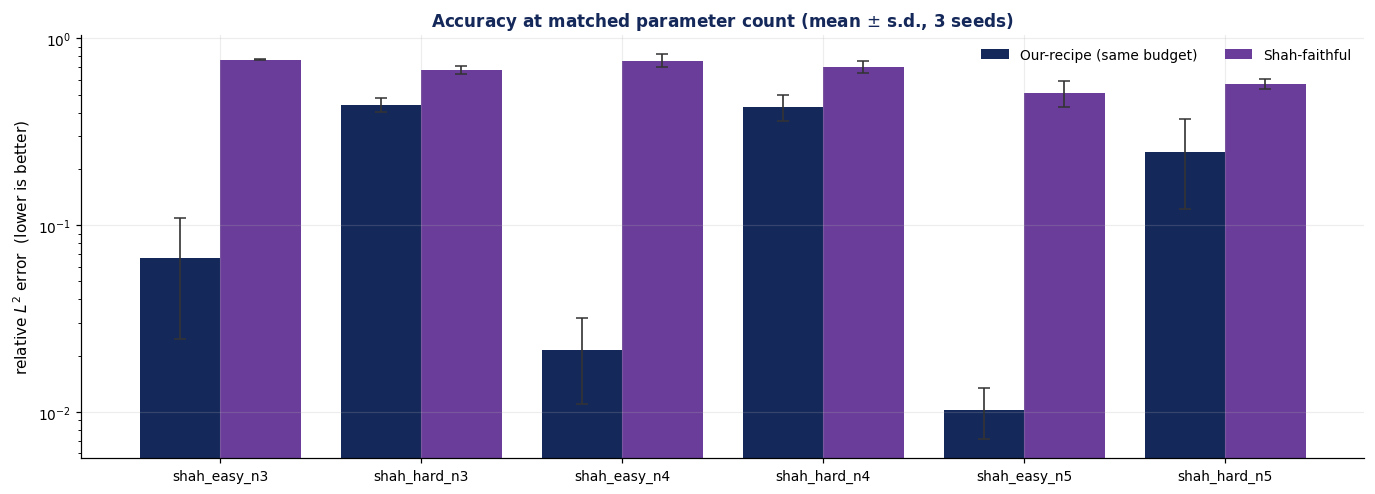

In [26]:
fig_headline(CONFIGS, SEEDS)

[fig] F2_seed_spread.png / .pdf


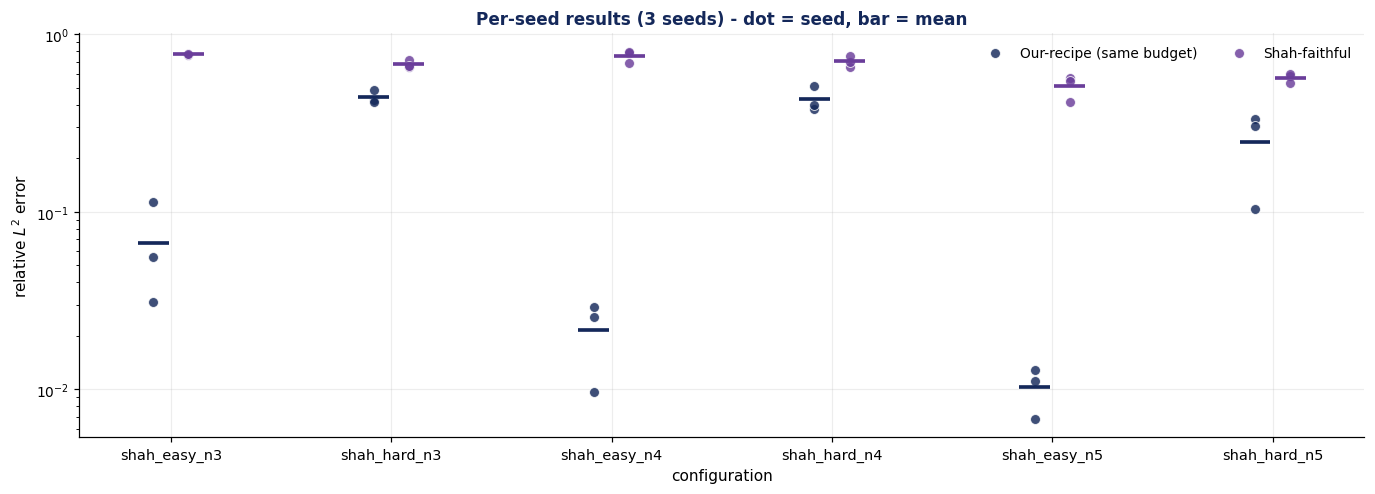

In [27]:
fig_seed_spread(CONFIGS, SEEDS)

### Table I figure - Shah reported vs faithful vs recipe

[fig] F0_table1_reproduction.png / .pdf


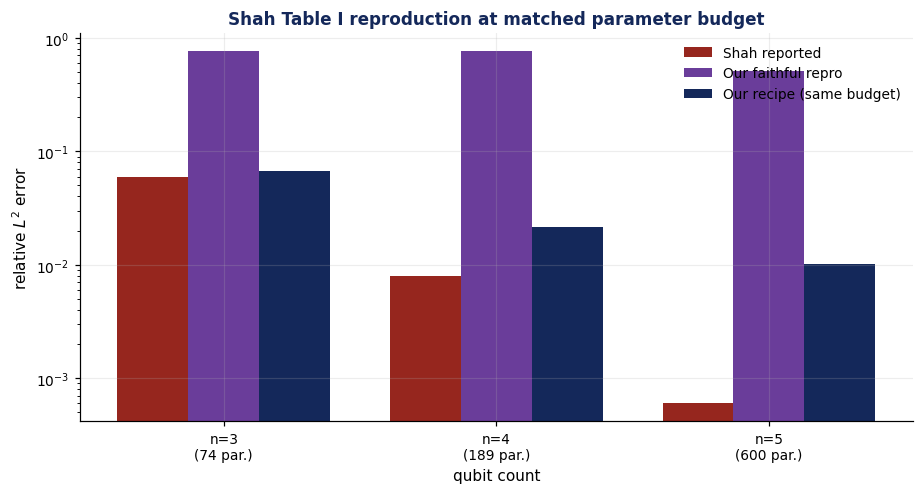

In [28]:
if REPRO_TABLE:
    ns = sorted(REPRO_TABLE); xp = np.arange(len(ns)); w = 0.26
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.bar(xp-w, [REPRO_TABLE[n]["shah"] for n in ns], w, color=C_REF, label="Shah reported")
    ax.bar(xp,   [REPRO_TABLE[n]["faithful"] for n in ns], w, color=C_ACC, label="Our faithful repro")
    ax.bar(xp+w, [REPRO_TABLE[n]["recipe"] for n in ns], w, color=C_Q, label="Our recipe (same budget)")
    ax.set_yscale("log"); ax.set_xticks(xp)
    ax.set_xticklabels([f"n={n}\n({REPRO_TABLE[n]['params']} par.)" for n in ns])
    ax.set_ylabel("relative $L^2$ error"); ax.set_xlabel("qubit count")
    ax.set_title("Shah Table I reproduction at matched parameter budget",
                 weight="bold", color=C_Q)
    ax.legend(loc="best", frameon=False)
    plt.tight_layout(); savefig(fig, "F0_table1_reproduction"); plt.show()

[fig] F3_neuron_profiles_shah_easy_n3_L1.png / .pdf


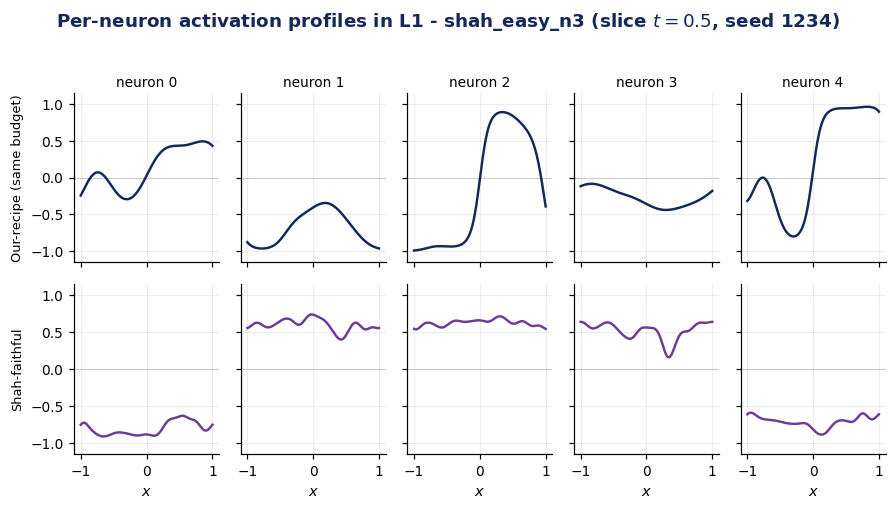

In [29]:
for c,*_ in CONFIGS:
    if (c,"recipe",SEEDS[0]) in ACTS: fig_neuron_profiles(c,"L1"); break

[fig] F4_histograms_shah_easy_n3_shah.png / .pdf


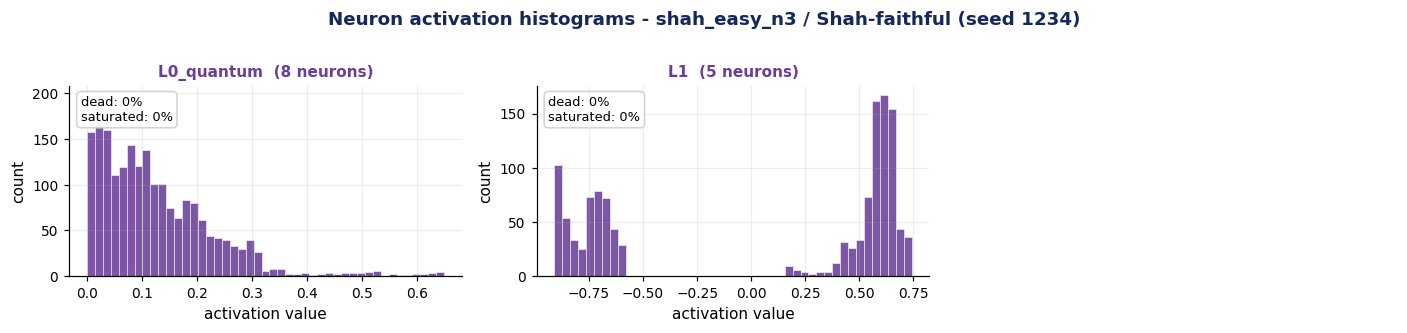

In [30]:
for c,*_ in CONFIGS:
    if (c,"shah",SEEDS[0]) in ACTS: fig_neuron_histograms(c,"shah"); break

[fig] F6_cka_shah_easy_n3.png / .pdf


/tmp/ipykernel_12665/1071041281.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  savefig(fig, f"F6_cka_{label}"); plt.tight_layout(); plt.show()


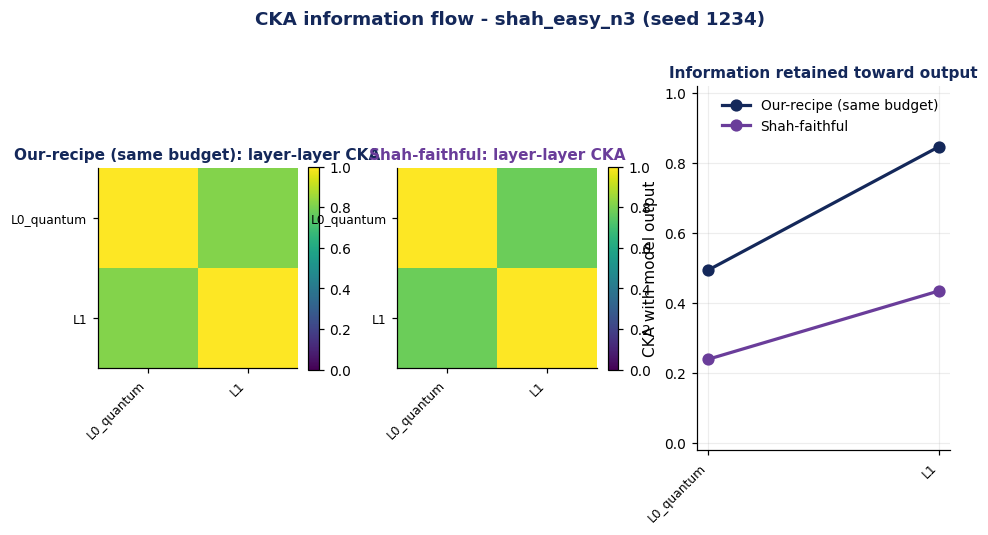

In [31]:
for c,*_ in CONFIGS:
    if (c,"recipe",SEEDS[0]) in CKA_STORE: fig_cka(c); break

[fig] F8_spectrum_shah_easy_n3.png / .pdf


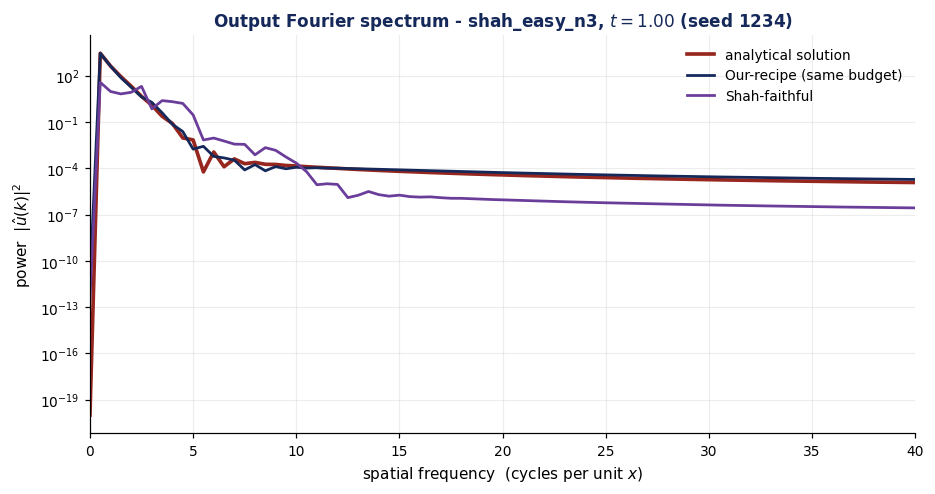

In [32]:
for c,*_ in CONFIGS:
    if (c,"recipe",SEEDS[0]) in RESULTS: fig_spectrum(c); break

---
## Phase-3 manifest

In [33]:
def write_manifest(configs, seeds, note):
    manifest = {
        "created": time.strftime("%Y-%m-%d %H:%M"),
        "notebook": note, "seeds": list(seeds),
        "configs": [{"label": l, "pde": p, "nu": float(n), "n_features": nf}
                    for l, p, n, nf in configs],
        "models_present": sorted({k for (_, k, _) in RESULTS}),
        "phase3_inputs": {
            "WS-A Fourier": "spectra/*_spectrum.npz, *_neuron_spectra.npz",
            "WS-B trainability": "gradients/gradient_variance.npz",
            "WS-C CKA/XAI": "cka_*.npz, activations/*_acts.npz",
        },
        "metrics_table": "metrics_table.csv",
    }
    with open(os.path.join(P3DIR, "manifest.json"), "w") as fh:
        json.dump(manifest, fh, indent=2)
    print("PHASE-3 INPUT BUNDLE READY\n" + "="*52)
    for root, _, files in os.walk(P3DIR):
        rel = os.path.relpath(root, P3DIR)
        if files: print(f"  {rel if rel != '.' else '(root)'}: {len(files)} files")
    n_dead = sum(1 for r in RESULTS.values() if r["dead"])
    print(f"\ntraining runs completed: {len(RESULTS)}")
    print(f"dead runs after retry: {n_dead}" + ("  <-- investigate" if n_dead else "  (none)"))
    print(f"figures: {FIGDIR}/  (PNG 300 dpi + vector PDF)")
print("[ok] manifest writer ready")

[ok] manifest writer ready


In [34]:
write_manifest(CONFIGS, SEEDS, "2-shah-fidelity (Track A, Djabon)")

PHASE-3 INPUT BUNDLE READY
  (root): 38 files
  activations: 36 files
  spectra: 72 files
  generalization: 1 files

training runs completed: 36
dead runs after retry: 1  <-- investigate
figures: qapinn_runs_shah/figures/  (PNG 300 dpi + vector PDF)
